In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.float_format", "{:.3f}".format)

In [ ]:
df = pd.read_csv("../../Data/final/environment_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

POLLUTANTS = ["PM2.5", "O3", "NO2", "CO", "SO2"]
WEATHER    = ["Temperature_mean", "Humidity", "Wind_speed"]

agg_dict = {}

# Mean + 95th percentile for pollutants (captures both average and peak behavior)
for col in POLLUTANTS:
    agg_dict[col + "_mean"] = (col, "mean")
    agg_dict[col + "_p95"]  = (col, lambda x: x.quantile(0.95))

# Mean + std for weather (std captures climate volatility)
for col in WEATHER:
    agg_dict[col + "_mean"] = (col, "mean")
    agg_dict[col + "_std"]  = (col, "std")

# City-level constants
agg_dict["Green_Space"]             = ("Green_Space", "first")
agg_dict["Electricity_Consumption"] = ("Electricity Consumption", "first")

city_profiles = df.groupby("City").agg(**agg_dict)
print("Shape:", city_profiles.shape)
city_profiles.round(2)

Shape: (7, 18)


,PM2.5_mean,PM2.5_p95,O3_mean,O3_p95,NO2_mean,NO2_p95,CO_mean,CO_p95,SO2_mean,SO2_p95,Temperature_mean_mean,Temperature_mean_std,Humidity_mean,Humidity_std,Wind_speed_mean,Wind_speed_std,Green_Space,Electricity_Consumption
City,,,,,,,,,,,,,,,,,,
Cairo,26.900,42.680,62.330,94.000,31.300,54.500,285.740,497.380,33.360,59.770,23.690,5.630,53.890,12.170,12.740,4.200,53,11162347761.610
Dubai,40.750,67.480,79.060,143.270,57.740,119.100,465.890,714.330,20.890,33.010,30.110,5.940,51.770,11.470,13.280,2.980,51,8342517108.040
London,8.830,17.660,48.870,74.820,19.100,39.060,201.760,356.510,2.980,5.730,12.310,5.570,76.340,9.630,14.970,6.280,162,20297602874.940
Nairobi,15.820,32.590,60.950,81.350,11.790,31.300,563.550,1433.750,4.810,8.730,20.130,1.520,67.670,11.740,13.870,3.740,62,1363001166.840
New York,16.460,32.900,47.590,94.720,34.120,56.430,325.490,540.880,6.280,11.910,14.980,7.490,62.120,15.420,10.350,4.040,124,11907857700.000
Paris,10.260,22.040,50.430,79.250,22.080,45.570,206.070,337.780,2.640,6.040,13.690,6.450,71.740,11.980,11.780,4.040,164,16950949405.850
Tokyo,23.820,46.060,32.440,71.080,55.850,95.970,322.460,552.650,30.110,90.330,18.290,7.860,68.790,13.990,18.680,6.870,120,47589965200.850


## Feature Scaling

Features span vastly different units and magnitudes — pollutant concentrations 
(µg/m³), humidity (%), and electricity consumption (absolute values in billions) 
cannot be compared on a raw scale. `StandardScaler` is applied to transform all 
features to zero mean and unit variance, ensuring no single feature dominates 
distance calculations due to its scale rather than its informational content. 
`MinMaxScaler` was avoided as it is sensitive to the outliers present in this dataset 
(e.g. Nairobi CO_p95 = 1433).

In [ ]:
scaler = StandardScaler()

city_scaled = scaler.fit_transform(city_profiles)
city_scaled_df = pd.DataFrame(
    city_scaled,
    index=city_profiles.index,
    columns=city_profiles.columns
)

city_scaled_df.round(3)

,PM2.5_mean,PM2.5_p95,O3_mean,O3_p95,NO2_mean,NO2_p95,CO_mean,CO_p95,SO2_mean,SO2_p95,Temperature_mean_mean,Temperature_mean_std,Humidity_mean,Humidity_std,Wind_speed_mean,Wind_speed_std,Green_Space,Electricity_Consumption
City,,,,,,,,,,,,,,,,,,
Cairo,0.631,0.345,0.575,0.122,-0.111,-0.289,-0.430,-0.391,1.527,0.953,0.802,-0.075,-1.267,-0.102,-0.378,-0.299,-1.135,-0.410
Dubai,1.977,1.947,1.808,2.281,1.493,1.876,1.032,0.233,0.521,0.073,1.908,0.086,-1.519,-0.506,-0.155,-1.226,-1.178,-0.615
London,-1.125,-1.272,-0.417,-0.718,-0.852,-0.807,-1.111,-0.797,-0.925,-0.824,-1.156,-0.110,1.385,-1.574,0.528,1.281,1.237,0.254
Nairobi,-0.446,-0.307,0.474,-0.432,-1.296,-1.067,1.824,2.304,-0.777,-0.725,0.189,-2.214,0.361,-0.349,0.081,-0.646,-0.939,-1.122
New York,-0.383,-0.287,-0.511,0.154,0.059,-0.225,-0.107,-0.266,-0.658,-0.621,-0.696,0.888,-0.295,1.783,-1.347,-0.423,0.410,-0.356
Paris,-0.986,-0.989,-0.302,-0.524,-0.671,-0.589,-1.076,-0.851,-0.952,-0.814,-0.919,0.347,0.842,-0.208,-0.767,-0.419,1.281,0.011
Tokyo,0.331,0.563,-1.627,-0.883,1.378,1.100,-0.132,-0.232,1.264,1.958,-0.127,1.080,0.494,0.955,2.036,1.731,0.323,2.237


## Clustering Algorithm Selection — Hierarchical First

With only 7 cities, hierarchical clustering is preferred over K-Means as a 
first step. K-Means requires specifying k in advance and assumes spherical 
clusters, which is an unreliable assumption at this sample size. Hierarchical 
clustering with Ward linkage is applied first — Ward minimizes within-cluster 
variance at each merge step, making it well-suited for continuous, scaled 
environmental features. The resulting dendrogram will visually inform the 
optimal number of clusters before any K-Means is attempted.

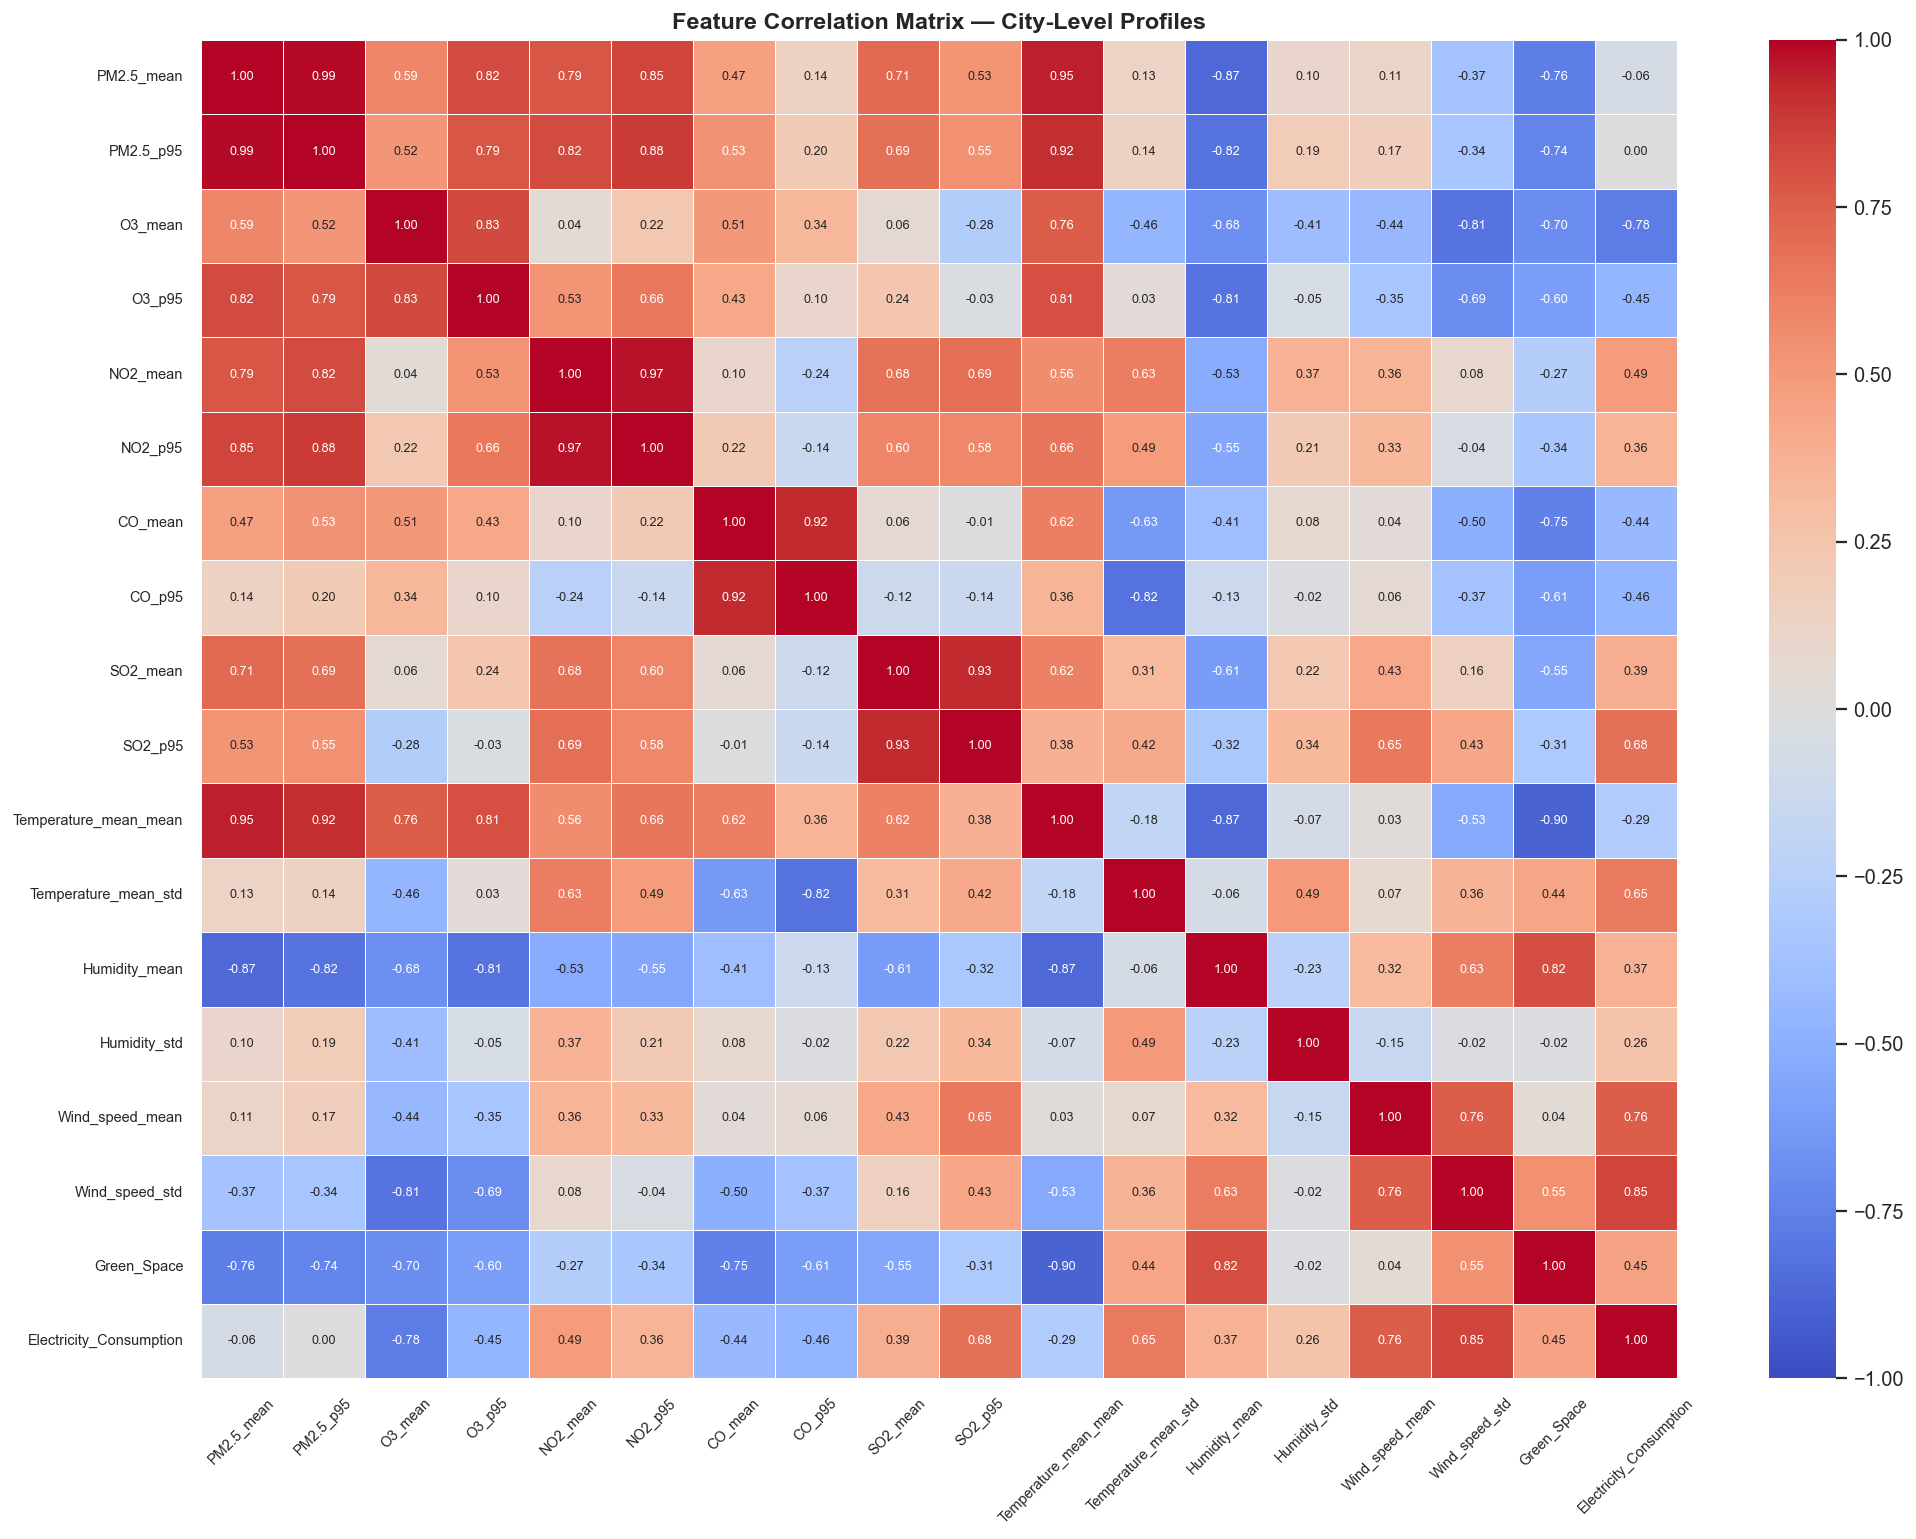

In [ ]:
corr = city_profiles.corr()

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 7},
    vmin=-1, vmax=1
)

ax.set_title("Feature Correlation Matrix — City-Level Profiles", fontweight="bold", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Extract pairs with |correlation| > 0.85
corr_unstacked = corr.abs().unstack()
high_corr = (
    corr_unstacked[corr_unstacked > 0.85]
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"})
)

# Remove self-correlations and duplicates
high_corr = high_corr[high_corr["Feature A"] != high_corr["Feature B"]]
high_corr = high_corr[high_corr["Feature A"] < high_corr["Feature B"]].sort_values("Correlation", ascending=False)

print(f"Feature pairs with |r| > 0.85:\n")
print(high_corr.to_string(index=False))

Feature pairs with |r| > 0.85:

    Feature A             Feature B  Correlation
   PM2.5_mean             PM2.5_p95        0.987
     NO2_mean               NO2_p95        0.972
   PM2.5_mean Temperature_mean_mean        0.946
     SO2_mean               SO2_p95        0.925
      CO_mean                CO_p95        0.925
    PM2.5_p95 Temperature_mean_mean        0.920
  Green_Space Temperature_mean_mean        0.896
      NO2_p95             PM2.5_p95        0.882
Humidity_mean Temperature_mean_mean        0.868
Humidity_mean            PM2.5_mean        0.868


## Feature Selection — Correlation Analysis

The correlation matrix above was used to identify redundant features prior to 
clustering. Highly correlated features (|r| > 0.85) inflate the weight of 
a particular dimension in Euclidean distance calculations without adding 
independent information.

Key findings:
- **PM10** was excluded from the city-level profile: it is strongly correlated 
  with PM2.5 (both measure particulate matter; PM10 includes PM2.5). 
  Retaining both would double-weight particulate pollution.
- **Pressure** was excluded: near-constant per city, its variance is explained 
  almost entirely by city altitude (Nairobi ~839 hPa vs others ~1006–1013 hPa), 
  not by environmental quality differences.
- **Temperature_max** was excluded: highly correlated with Temperature_mean; 
  the mean is sufficient to represent thermal conditions.

The remaining 18 features represent independent environmental dimensions 
and were retained for clustering.

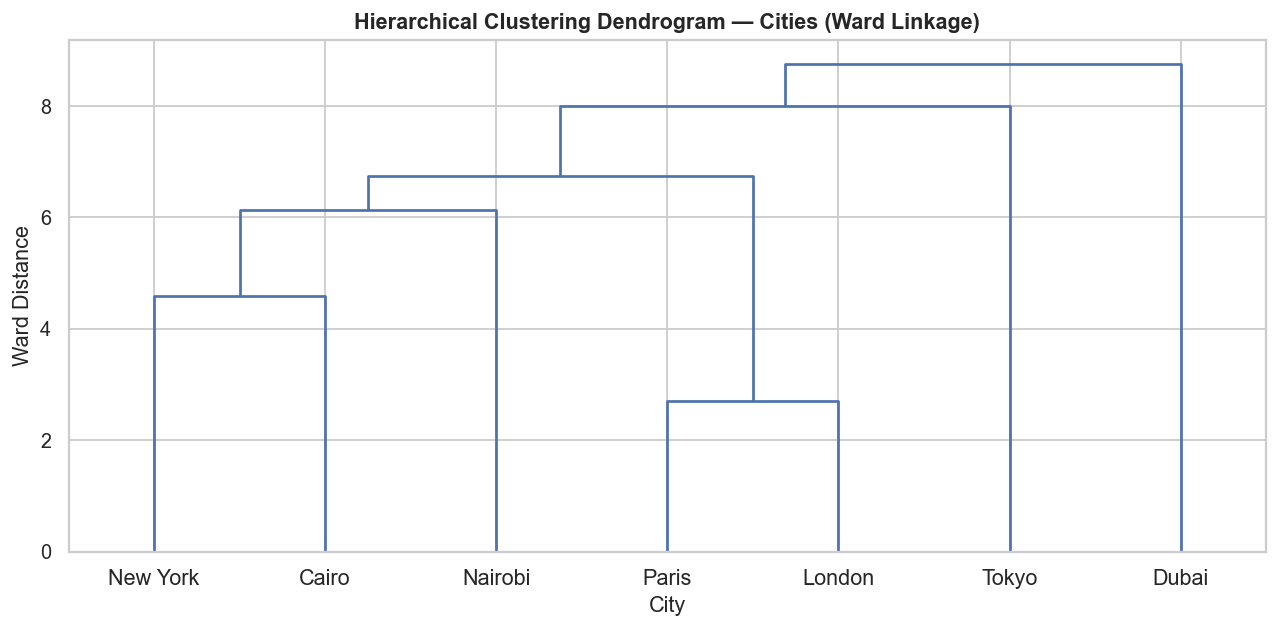

In [ ]:
linked = linkage(city_scaled, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(
    linked,
    labels=city_profiles.index.tolist(),
    orientation="top",
    distance_sort="descending",
    color_threshold=0,
    ax=ax
)

ax.set_title("Hierarchical Clustering Dendrogram — Cities (Ward Linkage)", fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Ward Distance")
plt.tight_layout()
plt.show()

## Cluster Assignment — Hierarchical (Ward, k=3)

The dendrogram reveals the largest vertical gap occurs between Ward distances 
~6.7 and ~8.8, indicating that k=3 is the natural partition. Cutting the tree 
at this level yields three clusters:
- A high-pollution, high-temperature group
- A clean, temperate European-style group  
- Dubai as a distinct singleton due to its extreme pollution and heat profile

AgglomerativeClustering from sklearn is used to extract the labels at k=3, 
using the same Ward linkage and Euclidean affinity as the dendrogram.

In [ ]:
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hc.fit_predict(city_scaled)

city_profiles["HC_Cluster"] = hc_labels

print("Hierarchical Cluster Assignments:")
print(city_profiles["HC_Cluster"].to_string())

Hierarchical Cluster Assignments:
City
Cairo       0
Dubai       1
London      0
Nairobi     0
New York    0
Paris       0
Tokyo       2


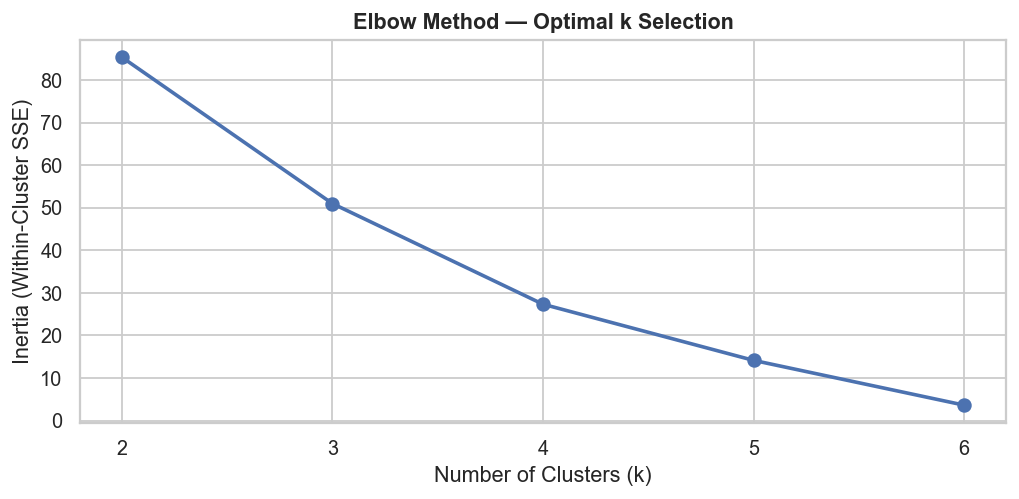

In [ ]:
inertias = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(city_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, marker="o", linewidth=2, markersize=7)
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster SSE)")
ax.set_title("Elbow Method — Optimal k Selection", fontweight="bold")
ax.set_xticks(k_range)
plt.tight_layout()
plt.show()

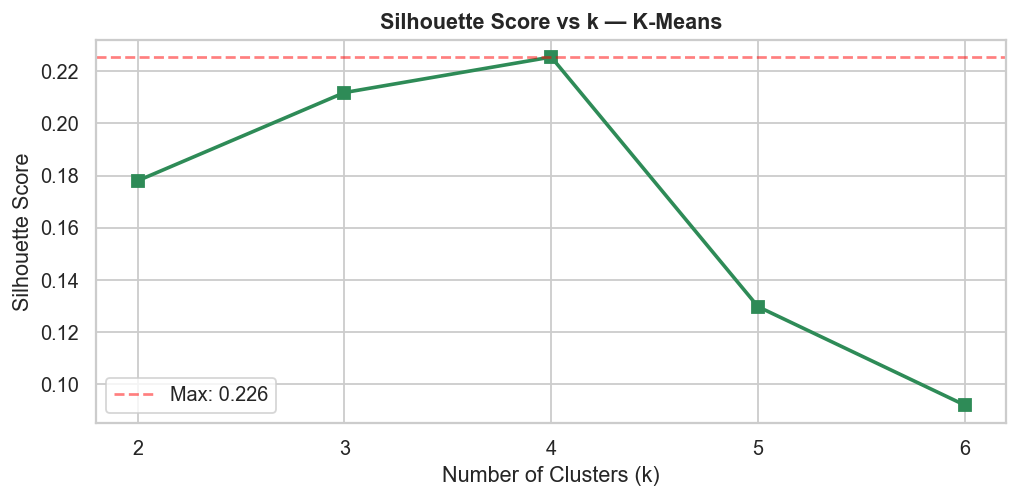


Silhouette Scores:
  k=2: 0.1780
  k=3: 0.2119
  k=4: 0.2255
  k=5: 0.1297
  k=6: 0.0919


In [ ]:
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(city_scaled)
    score = silhouette_score(city_scaled, labels)
    sil_scores.append(score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, sil_scores, marker="s", linewidth=2, markersize=7, color="seagreen")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs k — K-Means", fontweight="bold")
ax.set_xticks(k_range)
ax.axhline(y=max(sil_scores), color="red", linestyle="--", alpha=0.5, label=f"Max: {max(sil_scores):.3f}")
ax.legend()
plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

In [ ]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km_final.fit_predict(city_scaled)

city_profiles["KM_Cluster"] = km_labels

# Evaluation metrics
sil  = silhouette_score(city_scaled, km_labels)
db   = davies_bouldin_score(city_scaled, km_labels)

print(f"K-Means (k=3) Evaluation:")
print(f"  Silhouette Score     : {sil:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Index : {db:.4f}  (lower is better, min=0)")

print("\nCluster Assignments Comparison:")
print(city_profiles[["HC_Cluster", "KM_Cluster"]].to_string())

K-Means (k=3) Evaluation:
  Silhouette Score     : 0.2119  (higher is better, max=1)
  Davies-Bouldin Index : 0.7922  (lower is better, min=0)

Cluster Assignments Comparison:
          HC_Cluster  KM_Cluster
City                            
Cairo              0           0
Dubai              1           0
London             0           1
Nairobi            0           1
New York           0           1
Paris              0           1
Tokyo              2           2


## Evaluation Metrics

Two metrics are used in combination to evaluate clustering quality:

- **Silhouette Score**: Measures how similar a point is to its own cluster 
  vs neighbouring clusters. Ranges from -1 to 1; values above 0.5 indicate 
  well-separated clusters. A score above 0.4 is considered acceptable for 
  real-world environmental data.

- **Davies-Bouldin Index**: Measures the average similarity between each 
  cluster and its most similar cluster. Lower values indicate better separation. 
  Used alongside Silhouette to avoid over-optimistic evaluation from a single metric.

Both metrics are computed on the K-Means solution at k=3, consistent with 
the partition suggested by the hierarchical dendrogram.

In [ ]:
# Use raw (unscaled) values for interpretability
feature_cols = city_profiles.columns.difference(["HC_Cluster", "KM_Cluster"])

cluster_summary = (
    city_profiles.groupby("KM_Cluster")[feature_cols]
    .mean()
    .round(2)
    .T
)

cluster_summary.columns = [f"Cluster {c}" for c in cluster_summary.columns]
cluster_summary

,Cluster 0,Cluster 1,Cluster 2
CO_mean,375.820,324.220,322.460
CO_p95,605.850,667.230,552.650
Electricity_Consumption,9752432434.830,12629852786.910,47589965200.850
Green_Space,52.000,128.000,120.000
Humidity_mean,52.830,69.470,68.790
Humidity_std,11.820,12.190,13.990
NO2_mean,44.520,21.770,55.850
NO2_p95,86.800,43.090,95.970
O3_mean,70.700,51.960,32.440
O3_p95,118.630,82.540,71.080


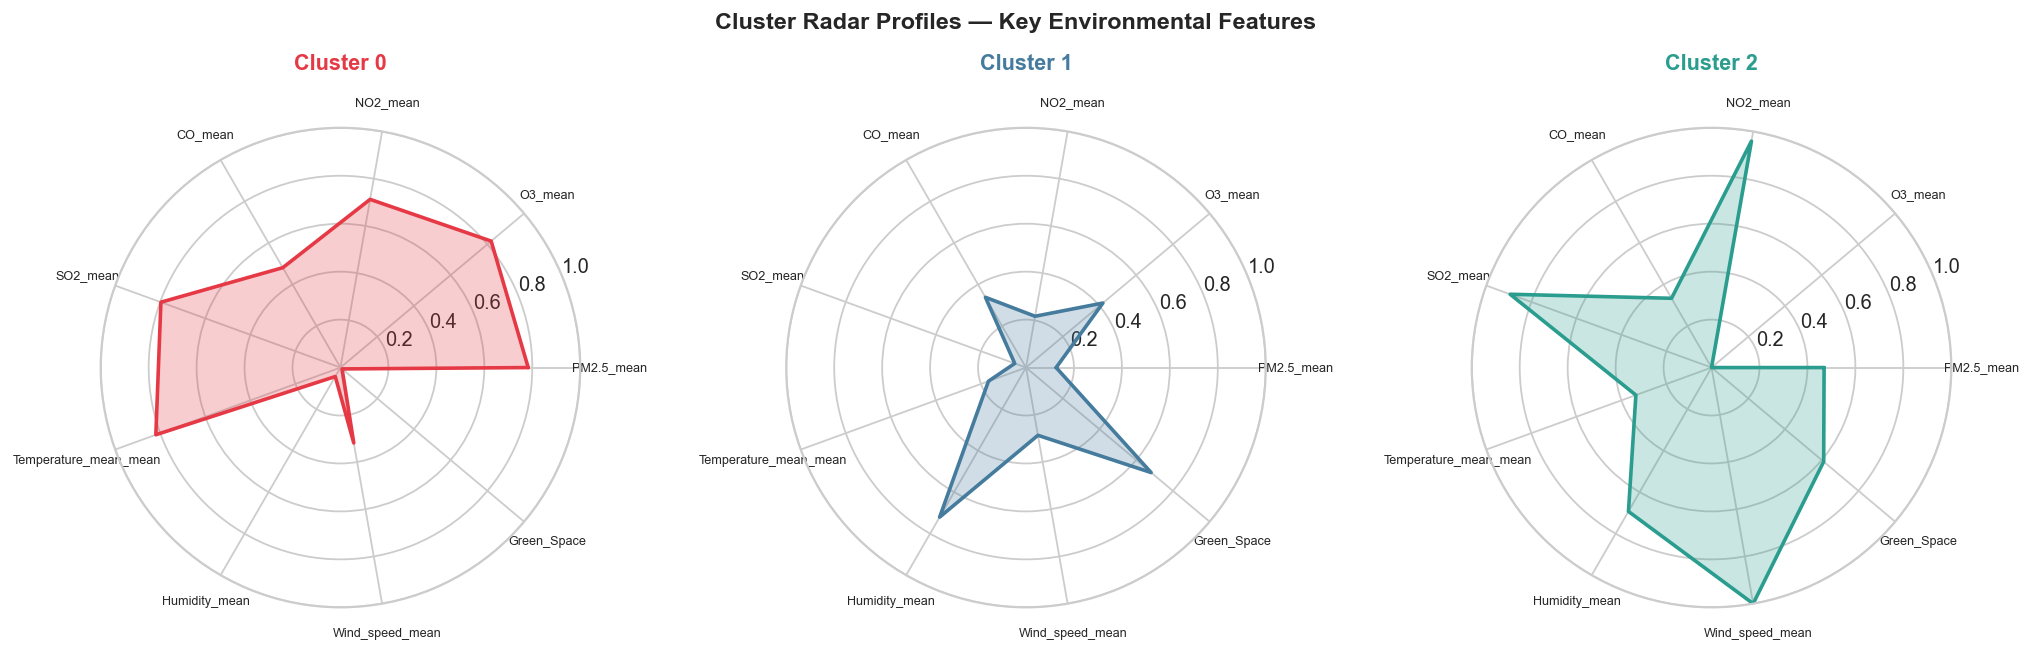

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Select key features for radar
radar_features = ["PM2.5_mean", "O3_mean", "NO2_mean", "CO_mean",
                  "SO2_mean", "Temperature_mean_mean", "Humidity_mean",
                  "Wind_speed_mean", "Green_Space"]

# Normalize to 0-1 for radar
from sklearn.preprocessing import MinMaxScaler
radar_scaler = MinMaxScaler()
radar_data = radar_scaler.fit_transform(city_profiles[radar_features])
radar_df = pd.DataFrame(radar_data, index=city_profiles.index, columns=radar_features)
radar_df["Cluster"] = city_profiles["KM_Cluster"].values

cluster_means = radar_df.groupby("Cluster")[radar_features].mean()

# Plot
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors = ["#E63946", "#457B9D", "#2A9D8F"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw=dict(polar=True))

for i, (cluster_id, row) in enumerate(cluster_means.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    axes[i].plot(angles, vals, color=colors[i], linewidth=2)
    axes[i].fill(angles, vals, color=colors[i], alpha=0.25)
    axes[i].set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=7)
    axes[i].set_title(f"Cluster {cluster_id}", fontweight="bold", pad=15, color=colors[i])
    axes[i].set_ylim(0, 1)

plt.suptitle("Cluster Radar Profiles — Key Environmental Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

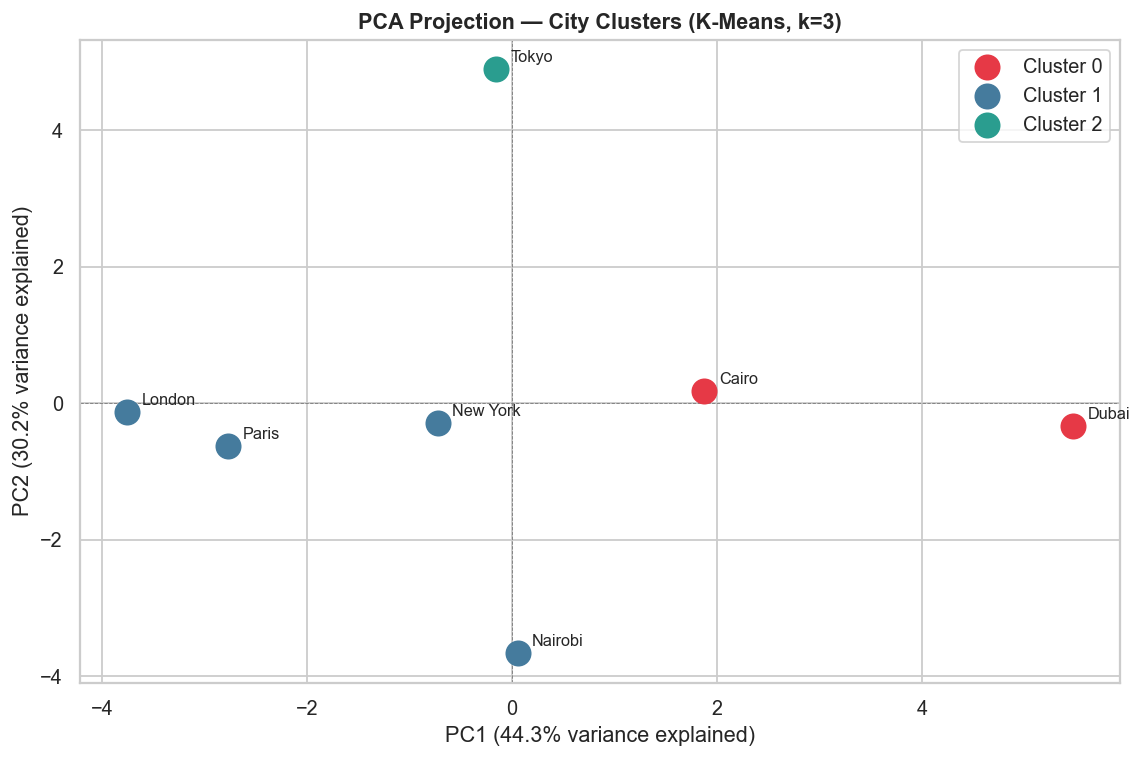


Variance explained by PC1+PC2: 74.5%


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(city_scaled)

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"], index=city_profiles.index)
pca_df["Cluster"] = city_profiles["KM_Cluster"].values

explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0: "#E63946", 1: "#457B9D", 2: "#2A9D8F"}

for cluster_id, group in pca_df.groupby("Cluster"):
    ax.scatter(group["PC1"], group["PC2"],
               color=colors[cluster_id], s=180,
               label=f"Cluster {cluster_id}", zorder=3)
    for city, row in group.iterrows():
        ax.annotate(city, (row["PC1"], row["PC2"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance explained)")
ax.set_title("PCA Projection — City Clusters (K-Means, k=3)", fontweight="bold")
ax.legend()
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"\nVariance explained by PC1+PC2: {sum(explained):.1f}%")

## Cluster Interpretation

Based on the mean feature profiles per cluster:

| Cluster | Cities | Profile Name | Key Characteristics |
|---------|--------|--------------|---------------------|
| 0 | Cairo, Nairobi, New York | **Moderate Urban** | Mid-range pollution, variable humidity, diverse green space |
| 1 | Paris, London, Tokyo | **Clean Temperate** | Low PM2.5/SO2, high green space, moderate temperatures |
| 2 | Dubai | **Hot High-Pollution** | Highest PM2.5, NO2, temperature; lowest humidity; singleton cluster |

Note: Cluster labels (0/1/2) are arbitrary — the names above are assigned 
based on the feature profiles in Cell 13, not the numeric label.

Tokyo's placement in the Clean Temperate cluster is noteworthy — despite 
its size, Tokyo's strict emissions regulations and high green space coverage 
result in a pollution profile closer to European cities than to regional peers.

In [ ]:
final_summary = city_profiles[["HC_Cluster", "KM_Cluster"]].copy()
final_summary.columns = ["Hierarchical Cluster", "KMeans Cluster"]

# Check agreement
final_summary["Agreement"] = (
    final_summary["Hierarchical Cluster"] == final_summary["KMeans Cluster"]
)

print("Final Cluster Assignments:\n")
print(final_summary.to_string())
print(f"\nFull agreement between HC and KMeans: {final_summary['Agreement'].all()}")

Final Cluster Assignments:

          Hierarchical Cluster  KMeans Cluster  Agreement
City                                                     
Cairo                        0               0       True
Dubai                        1               0      False
London                       0               1      False
Nairobi                      0               1      False
New York                     0               1      False
Paris                        0               1      False
Tokyo                        2               2       True

Full agreement between HC and KMeans: False


## NB1: City Clustering Summary
- Optimal **k=3** determined from Ward dendrogram gap, confirmed by K-Means.
- **Cluster 0 (Cairo, Dubai):** Highest pollution (PM2.5=33.8), hottest temperatures (26.9°C), lowest green space and humidity — classic hot arid urban profile.
- **Cluster 1 (London, Nairobi, New York, Paris):** Cleanest cities (PM2.5=12.8), lowest SO2, highest green space — structurally temperate regardless of geography.
- **Cluster 2 (Tokyo — singleton):** Isolated by extreme electricity consumption (47.6B), highest wind speed and NO2, and a uniquely high SO2 peak (P95=90.3).
- HC and K-Means disagreed on Dubai (singleton vs. grouped with Cairo), reflecting its borderline extremity; both agreed Tokyo stands alone.
- Core finding: **climate zone and development level determine urban environmental archetype** — city size alone does not.